
Si_R1s(r) =
+64.9362 * exp(-19.5017 r)
+36.6269 * exp(-11.7539 r)
+274.7509 * r * exp(-16.9664 r)
+0.1762 * r * exp(-6.3693 r)
+0.0063 * r * exp(-4.5748 r)
-0.0109 * r * exp(-3.3712 r)
-63.2630 * r^2 * exp(-36.5764 r)
+0.0011 * r^2 * exp(-2.4996 r)
-0.0001 * r^2 * exp(-1.6627 r)
+0.0000 * r^2 * exp(-1.1812 r)

Si_R2s(r) =
+11.0617 * exp(-19.5017 r)
-38.0912 * exp(-11.7539 r)
+75.8263 * r * exp(-16.9664 r)
+27.6402 * r * exp(-6.3693 r)
+40.4168 * r * exp(-4.5748 r)
+2.3282 * r * exp(-3.3712 r)
+32.0682 * r^2 * exp(-36.5764 r)
-0.0191 * r^2 * exp(-2.4996 r)
+0.0022 * r^2 * exp(-1.6627 r)
-0.0000 * r^2 * exp(-1.1812 r)

Si_R3s(r) =
+4.0525 * exp(-19.5017 r)
-10.9775 * exp(-11.7539 r)
+26.9211 * r * exp(-16.9664 r)
+8.7912 * r * exp(-6.3693 r)
+6.3361 * r * exp(-4.5748 r)
+4.9679 * r * exp(-3.3712 r)
+5.9894 * r^2 * exp(-36.5764 r)
-3.3217 * r^2 * exp(-2.4996 r)
-1.4060 * r^2 * exp(-1.6627 r)
-0.2118 * r^2 * exp(-1.1812 r)

Si_R2p(r) =
+17.7475 * r * exp(-15.7304 r)
+32.5960 * r * exp(-7.

/tmp/ipykernel_23766/3929121043.py:102: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00       6.337797e-02       2.749151e-01       1.036279e+00   
1       0.05       6.337524e-02       2.747071e-01       1.025057e+00   
2       0.10       6.336705e-02       2.740843e-01       9.922082e-01   
3       0.15       6.335341e-02       2.730500e-01       9.400784e-01   
4       0.20       6.333432e-02       2.716097e-01       8.722284e-01   
...      ...                ...                ...                ...   
1996   99.80       2.705948e-07       1.969279e-08       1.296407e-09   
1997   99.85       2.693947e-07       1.960508e-08       1.290632e-09   
1998   99.90       2.681986e-07       1.951767e-08       1.284877e-09   
1999   99.95       2.670067e-07       1.943056e-08       1.279142e-09   
2000  100.00       2.658188e-07       1.934376e-08       1.273426e-09   

      J_2p_one_electron  J_3p_one_electron       J_1s(2)       J_2s(2)  \
0          1.489565e-01       7.322887e-01  1.267

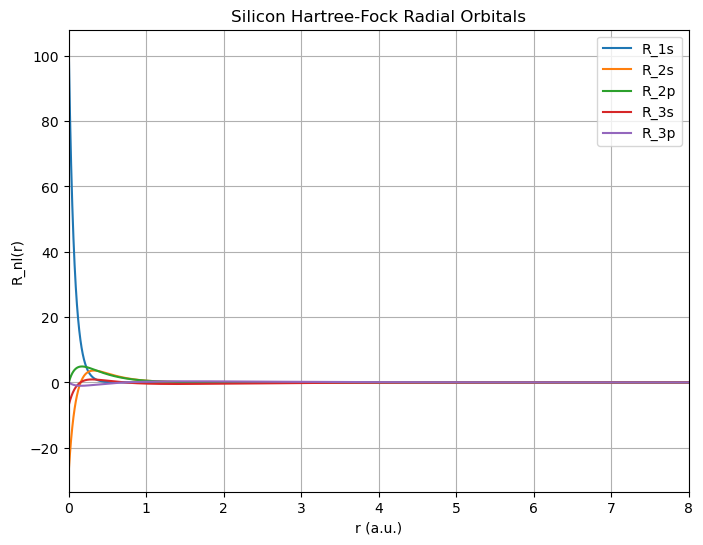

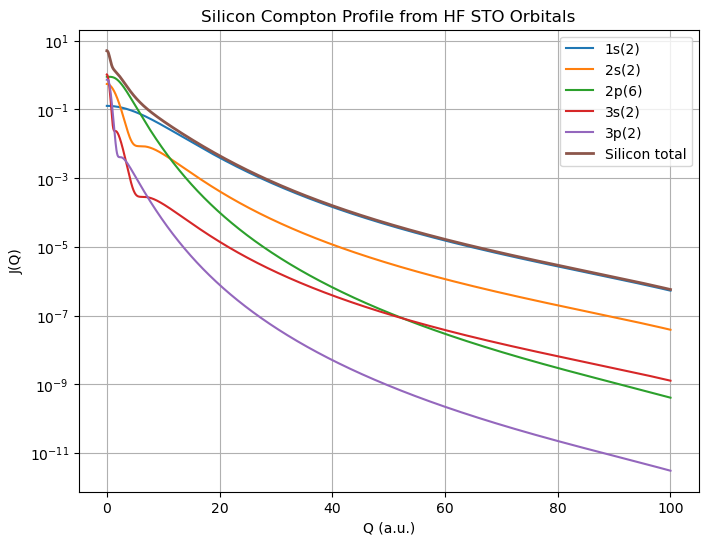

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Silicon Hartree-Fock STO data
# Si: 1s(2) 2s(2) 2p(6) 3s(2) 3p(2)
# Format: (n_j, Z_j, C_j)
# =====================================================

silicon_1s = [
    (1, 19.5017,  0.377006),
    (1, 11.7539,  0.454461),
    (2, 16.9664,  0.200676),
    (2,  6.3693,  0.001490),
    (2,  4.5748,  0.000121),
    (2,  3.3712, -0.000454),
    (3, 36.5764, -0.000507),
    (3,  2.4996,  0.000103),
    (3,  1.6627, -0.000053),
    (3,  1.1812,  0.000013),
]
silicon_2s = [
    (1, 19.5017,  0.064222),
    (1, 11.7539, -0.472631),
    (2, 16.9664,  0.055383),
    (2,  6.3693,  0.233799),
    (2,  4.5748,  0.781919),
    (2,  3.3712,  0.096627),
    (3, 36.5764,  0.000257),
    (3,  2.4996, -0.001832),
    (3,  1.6627,  0.000879),
    (3,  1.1812, -0.000033),
]
silicon_3s = [
    (1, 19.5017,  0.023528),
    (1, 11.7539, -0.136207),
    (2, 16.9664,  0.019663),
    (2,  6.3693,  0.074362),
    (2,  4.5748,  0.122580),
    (2,  3.3712,  0.206180),
    (3, 36.5764,  0.000048),
    (3,  2.4996, -0.319063),
    (3,  1.6627, -0.562578),
    (3,  1.1812, -0.280471),
]
silicon_2p = [
    (2, 15.7304, 0.015661),
    (2,  7.2926, 0.196557),
    (2,  4.6514, 0.510448),
    (2,  3.3983, 0.303956),
    (3, 12.0786, 0.025586),
    (3,  2.0349, 0.003153),
    (3,  1.3221, 0.000167),
    (3,  0.9143, 0.000156),
]
silicon_3p = [
    (2, 15.7304, -0.001966),
    (2,  7.2926, -0.057175),
    (2,  4.6514, -0.068127),
    (2,  3.3983, -0.114298),
    (3, 12.0786, -0.001976),
    (3,  2.0349,  0.263703),
    (3,  1.3221,  0.522698),
    (3,  0.9143,  0.314467),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build nitrogen radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, silicon_1s)
R2s = R_nl(r, silicon_2s)
R3s = R_nl(r, silicon_3s)
R2p = R_nl(r, silicon_2p)
R3p = R_nl(r, silicon_3p)

print_R_formula(silicon_1s, "Si_R1s")
print_R_formula(silicon_2s, "Si_R2s")
print_R_formula(silicon_3s, "Si_R3s")
print_R_formula(silicon_2p, "Si_R2p")
print_R_formula(silicon_3p, "Si_R3p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)

# Aluminium has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(2)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 2*J_3p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(2)": 2*J_3p,
    "J_total_Silicon": J_total
})
print(table)
table.to_csv("Silicon_HF_Compton_profile.csv", index=False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Silicon Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_3s, label="3s(2)")
plt.plot(Q, J_3p, label="3p(2)")
plt.plot(Q, J_total, label="Silicon total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Silicon Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()